# Import libraries

In [3]:
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
from collections import Counter
from torch.utils.data import DataLoader
from torch.nn.modules import ReLU
import torch.nn as nn
import torch.optim as optim
import torch

# Load Dataset

In [4]:
train_dataset = MNIST(root='./data', train=True, download=True, transform=ToTensor())
test_dataset = MNIST(root='./data', train=False, download=True, transform=ToTensor())

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 499kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.53MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.9MB/s]


# Data exploration

## The number and the shape of the Train and Test data

In [ ]:
print(f"Number of train data: {len(train_dataset)}")
print(f"Number of test data: {len(test_dataset)}")
print(f"Dimention of train data: {train_dataset[0][0].shape}")
print(f"Dimention of test data: {test_dataset[0][0].shape}")

Number of train data: 60000
Number of test data: 10000
Dimention of train data: torch.Size([1, 28, 28])
Dimention of test data: torch.Size([1, 28, 28])


##

## Show an example of each class

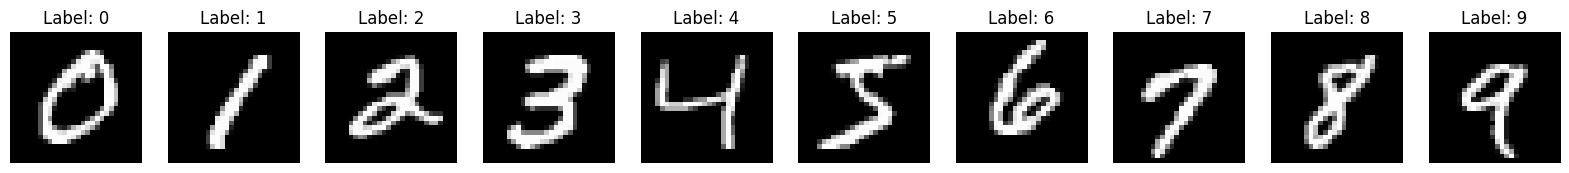

In [ ]:
class_samples = {}

for i in range(10):
    for x, y in train_dataset:
        if y == i:
            class_samples[i] = x
            break


fig, axs = plt.subplots(1, 10, figsize=(20, 2))

for i in range(10):
    # reshape image into (28*28)
    image = class_samples[i].squeeze()
    axs[i].imshow(image, cmap='gray')
    axs[i].axis('off')
    axs[i].set_title(f'Label: {i}')

plt.show()

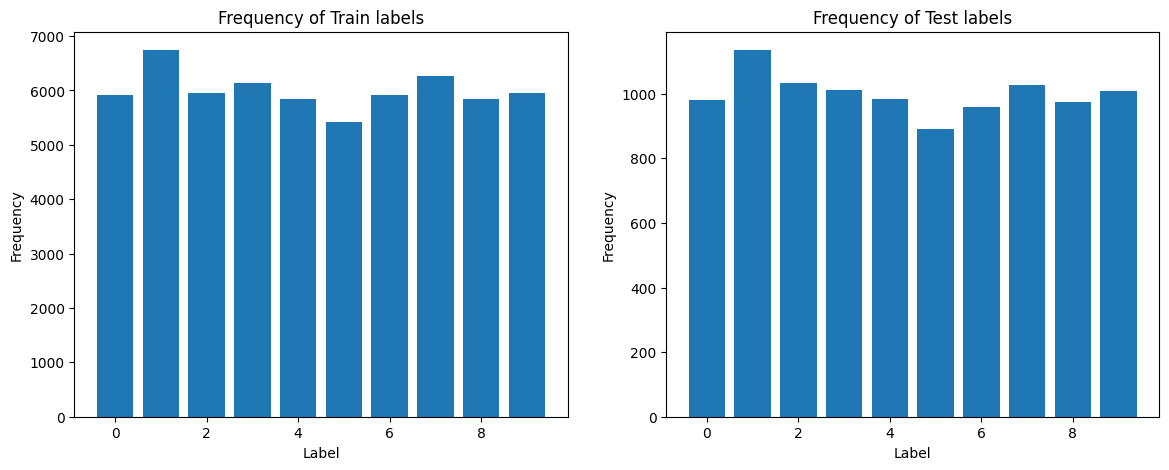

In [ ]:
all_train_labels = [train_dataset[i][1] for i in range(len(train_dataset))]
all_test_labels = [test_dataset[i][1] for i in range(len(test_dataset))]

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.bar(Counter(all_train_labels).keys(), Counter(all_train_labels).values())
plt.xlabel("Label")
plt.ylabel("Frequency")
plt.title("Frequency of Train labels")

plt.subplot(1, 2, 2)
plt.bar(Counter(all_test_labels).keys(), Counter(all_test_labels).values())
plt.xlabel("Label")
plt.ylabel("Frequency")
plt.title("Frequency of Test labels")
plt.show()


# Model training

## Data loader

In [5]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

## Model architecture

In [6]:
class MNIST_classifier(nn.Module):
  def __init__(self, num_class):
    super().__init__()

    self.classifier = nn.Sequential(
        nn.Linear(784, 512),
        nn.ReLU(),
        nn.Linear(512, 128),
        nn.ReLU(),
        nn.Linear(128, 32),
        nn.ReLU(),
        nn.Linear(32, num_class),
        nn.Softmax(dim=0)
    )

  def forward(self, x):
    x = x.view(-1, 28*28)
    return self.classifier(x)

## Training model

Epoch 1: Loss: 2.2908, Accuracy = 56.56%
Epoch 2: Loss: 2.2309, Accuracy = 62.40%
Epoch 3: Loss: 2.1990, Accuracy = 65.57%
Epoch 4: Loss: 2.1858, Accuracy = 68.32%
Epoch 5: Loss: 2.1804, Accuracy = 70.37%
Epoch 6: Loss: 2.1765, Accuracy = 72.37%
Epoch 7: Loss: 2.1748, Accuracy = 73.75%
Epoch 8: Loss: 2.1734, Accuracy = 74.37%
Epoch 9: Loss: 2.1727, Accuracy = 75.66%
Epoch 10: Loss: 2.1720, Accuracy = 76.09%
Epoch 11: Loss: 2.1718, Accuracy = 76.95%
Epoch 12: Loss: 2.1713, Accuracy = 77.72%
Epoch 13: Loss: 2.1708, Accuracy = 78.28%
Epoch 14: Loss: 2.1711, Accuracy = 78.35%
Epoch 15: Loss: 2.1705, Accuracy = 79.09%
Epoch 16: Loss: 2.1704, Accuracy = 79.63%
Epoch 17: Loss: 2.1698, Accuracy = 80.24%
Epoch 18: Loss: 2.1697, Accuracy = 80.67%
Epoch 19: Loss: 2.1696, Accuracy = 81.02%
Epoch 20: Loss: 2.1698, Accuracy = 81.20%
Epoch 21: Loss: 2.1694, Accuracy = 81.69%
Epoch 22: Loss: 2.1691, Accuracy = 82.32%
Epoch 23: Loss: 2.1691, Accuracy = 82.46%
Epoch 24: Loss: 2.1691, Accuracy = 82.70%
E

/tmp/ipykernel_2285/1376888412.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_2285/1376888412.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


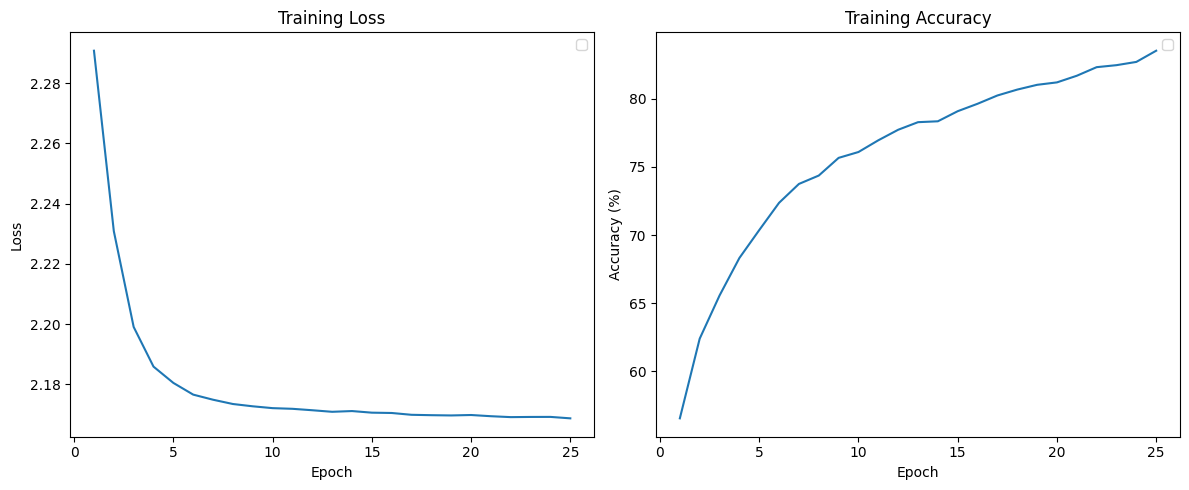

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MNIST_classifier(num_class=10).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss()

num_epoch = 25

train_loss = []
train_acc = []

for i in range(num_epoch):

  model.train()
  losses = 0
  acc = 0
  total = 0


  for im, la in train_loader:
    images = im.to(device)
    labels = la.to(device)

    output = model(images)
    prob = torch.argmax(output, dim=1)

    loss = criterion(output, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    acc += (prob == labels).sum().item()
    losses += loss.item() * images.size(0)
    total += images.size(0)

  print(f"Epoch {i+1}: Loss: {losses / total:.4f}, Accuracy = {acc / total*100:.2f}%")
  train_loss.append(losses / total)
  train_acc.append(acc / total*100)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss) + 1), train_loss)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc) + 1), train_acc)
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## Testing model

In [8]:
correct = 0
total = 0

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
      images = images.to(device)
      labels = labels.to(device)
      outputs = model(images.view(-1, 28*28))
      pred = torch.argmax(outputs, dim=1)
      total += labels.size(0)
      correct += (pred == labels).sum().item()


print(f"Accuracy without attack {correct / total * 100}%")
print(f'Total number of images is {total} and the number of images predicted correctly is {correct}')

Accuracy without attack 84.93%
Total number of images is 10000 and the number of images predicted correctly is 8493


# FGSM attack

In [ ]:
def FGSM_attack(model, image, label, epsilon):

    model.eval()

    image = image.clone().detach().requires_grad_(True)

    output = model(image)
    loss = nn.CrossEntropyLoss()(output, label)
    loss.backward()
    gradient = image.grad.detach()

    with torch.no_grad():
        noisy_image = image + gradient.sign() * epsilon

    return noisy_image


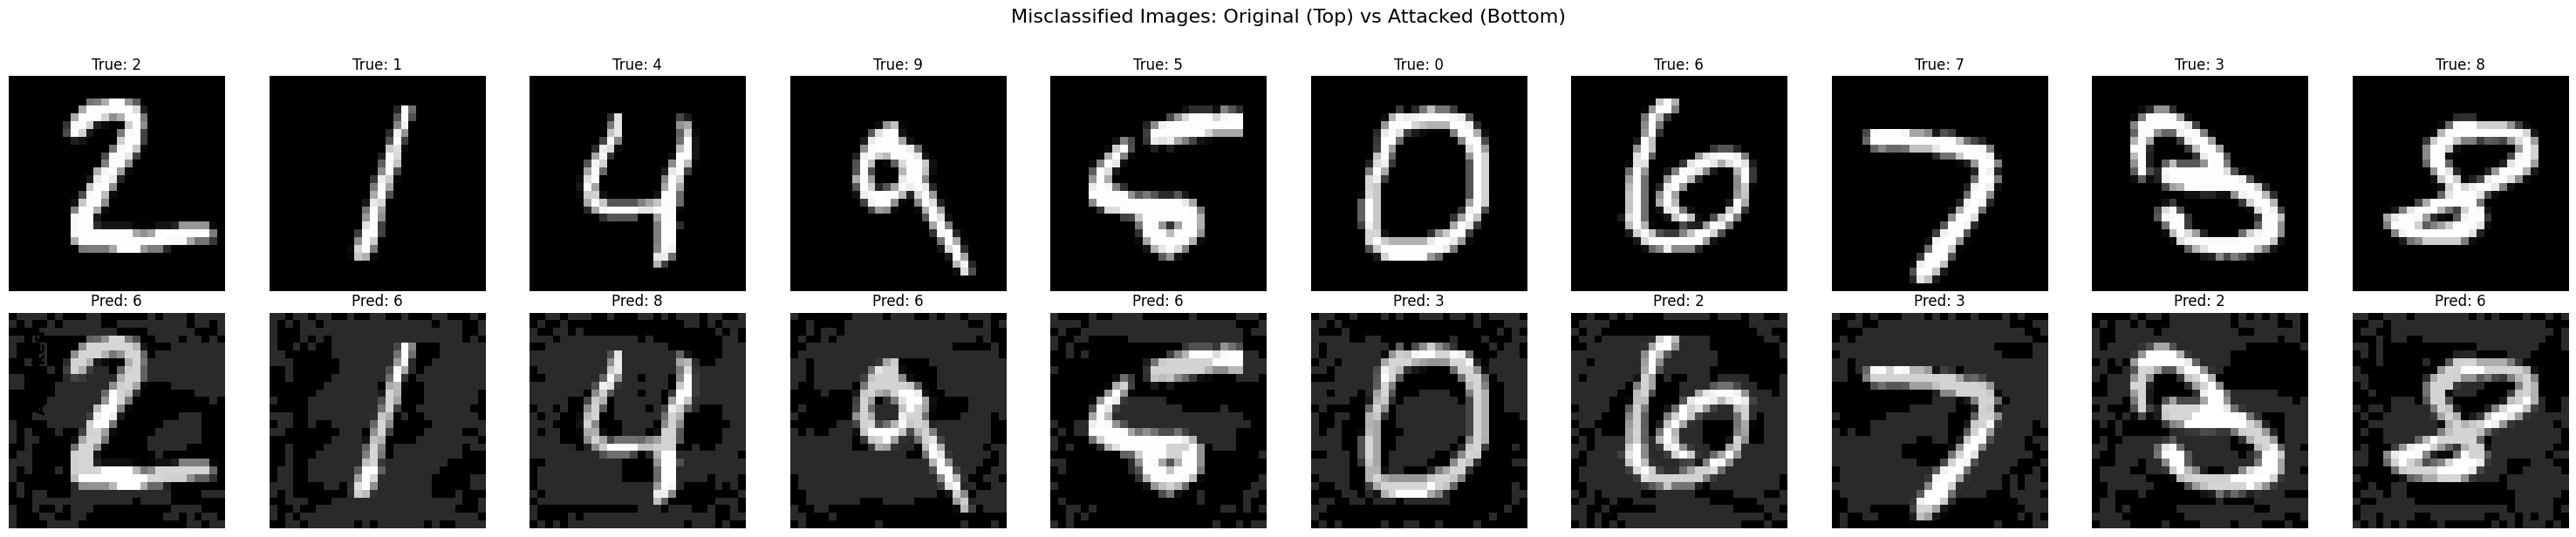


Accuracy without attack: 0.8484
Accuracy with attack: 0.2377
Number of images predicted correctly without attack: 33936
Number of images predicted correctly with attack: 9508
61.07% of attacks were successful


In [ ]:
misclassified_pairs = []
hist = []

noisy_correct = 0

for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)
    pred = torch.argmax(outputs, dim=1)
    correct += (pred == labels).sum().item()

    noisy_image = FGSM_attack(model, images, labels, epsilon=0.1)
    outputs = model(noisy_image)
    pred = torch.argmax(outputs, dim=1)
    total += labels.size(0)
    noisy_correct += (pred == labels).sum().item()

    for i in range(len(labels)):
        if (pred[i].item() != labels[i].item()) and (labels[i].item() not in hist):
            hist.append(labels[i].item())

            original_img = images[i].squeeze().detach().cpu().numpy()
            perturbed_img = noisy_image[i].squeeze().detach().cpu().numpy()
            misclassified_pairs.append({
                'original': original_img,
                'perturbed': perturbed_img,
                'true_label': labels[i].item(),
                'pred_label': pred[i].item()
            })

# Display misclassified images with original on top row, attacked on bottom row
if misclassified_pairs:
    num_to_show = min(10, len(misclassified_pairs))
    fig, axs = plt.subplots(2, num_to_show, figsize=(3*num_to_show, 6))

    for i in range(num_to_show):
        pair = misclassified_pairs[i]

        # Top row: Original images
        axs[0, i].imshow(pair['original'], cmap='gray')
        axs[0, i].axis('off')
        axs[0, i].set_title(f'True: {pair["true_label"]}', fontsize=12)

        # Bottom row: Attacked images
        axs[1, i].imshow(pair['perturbed'], cmap='gray')
        axs[1, i].axis('off')
        axs[1, i].set_title(f'Pred: {pair["pred_label"]}', fontsize=12)

    fig.text(0.02, 0.75, 'Original', fontsize=14, fontweight='bold', rotation=90)
    fig.text(0.02, 0.25, 'Attacked', fontsize=14, fontweight='bold', rotation=90)

    plt.suptitle(f'Misclassified Images: Original (Top) vs Attacked (Bottom)', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


print("\n" + "="*50)
print("Accuracy without attack:", correct / total)
print("Accuracy with attack:", noisy_correct / total)
print('Number of images predicted correctly without attack:', correct)
print('Number of images predicted correctly with attack:', noisy_correct)
print(f"{(correct - noisy_correct) / total * 100:.2f}% of attacks were successful")
print("="*50)

# PGD attack

In [9]:
def PGD_attack(model, x, y, epsilon, alpha, num_iter):

    x_adv = x.clone().detach().requires_grad_(True)

    # Iterative updates
    for t in range(num_iter):
        output = model(x_adv)
        loss = nn.CrossEntropyLoss()(output, y)

        model.zero_grad()
        loss.backward()

        grad = x_adv.grad.data

        x_adv = x_adv + alpha * grad.sign()

        x_adv = torch.clamp(x_adv, x - epsilon, x + epsilon)
        x_adv = torch.clamp(x_adv, 0, 1)  # Keep in valid pixel range

        x_adv = x_adv.detach().requires_grad_(True)

    return x_adv.detach()

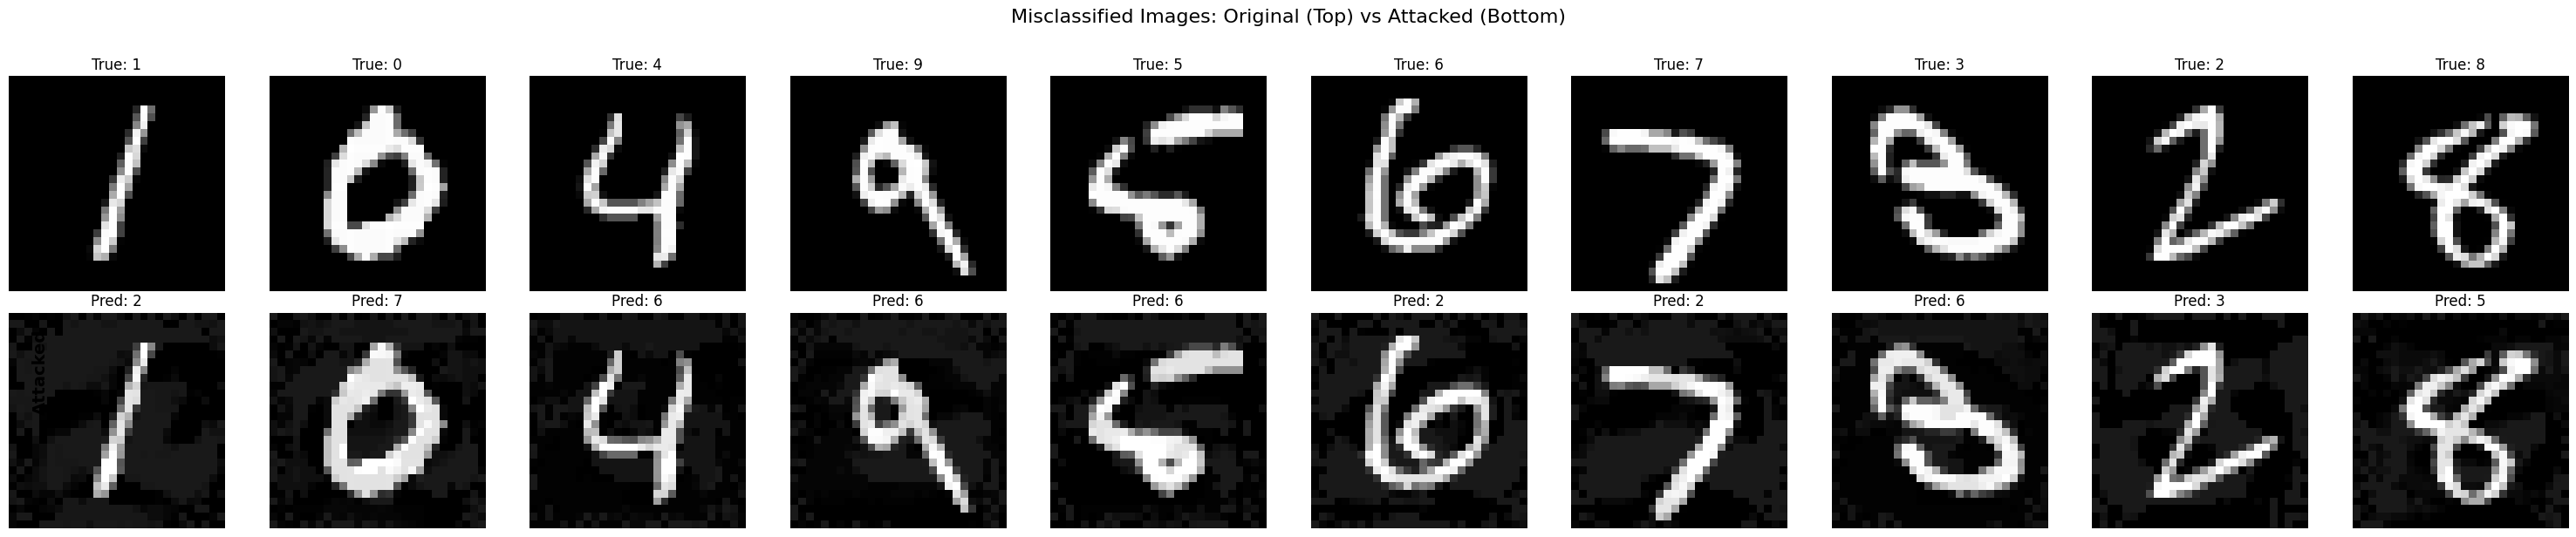


Accuracy without attack: 0.8493547099521022
Accuracy with attack: 0.12895822245875466
Number of images predicted correctly without attack: 25535
Number of images predicted correctly with attack: 3877
72.04% of attacks were successful


In [12]:
misclassified_pairs = []
hist = []
noisy_correct = 0

for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)
    pred = torch.argmax(outputs, dim=1)
    correct += (pred == labels).sum().item()

    noisy_image = PGD_attack(model, images, labels, epsilon=0.1, alpha=0.01, num_iter=10)
    outputs = model(noisy_image)
    pred = torch.argmax(outputs, dim=1)
    total += labels.size(0)
    noisy_correct += (pred == labels).sum().item()

    for i in range(len(labels)):
        if (pred[i].item() != labels[i].item()) and (labels[i].item() not in hist):
            hist.append(labels[i].item())

            original_img = images[i].squeeze().detach().cpu().numpy()
            perturbed_img = noisy_image[i].squeeze().detach().cpu().numpy()
            misclassified_pairs.append({
                'original': original_img,
                'perturbed': perturbed_img,
                'true_label': labels[i].item(),
                'pred_label': pred[i].item()
            })

# Display misclassified images with original on top row, attacked on bottom row
if misclassified_pairs:
    num_to_show = min(10, len(misclassified_pairs))
    fig, axs = plt.subplots(2, num_to_show, figsize=(3*num_to_show, 6))

    for i in range(num_to_show):
        pair = misclassified_pairs[i]

        # Top row: Original images
        axs[0, i].imshow(pair['original'], cmap='gray')
        axs[0, i].axis('off')
        axs[0, i].set_title(f'True: {pair["true_label"]}', fontsize=12)

        # Bottom row: Attacked images
        axs[1, i].imshow(pair['perturbed'], cmap='gray')
        axs[1, i].axis('off')
        axs[1, i].set_title(f'Pred: {pair["pred_label"]}', fontsize=12)

    fig.text(0.02, 0.75, 'Original', fontsize=14, fontweight='bold', rotation=90)
    fig.text(0.02, 0.25, 'Attacked', fontsize=14, fontweight='bold', rotation=90)

    plt.suptitle(f'Misclassified Images: Original (Top) vs Attacked (Bottom)', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


print("\n" + "="*50)
print("Accuracy without attack:", correct / total)
print("Accuracy with attack:", noisy_correct / total)
print('Number of images predicted correctly without attack:', correct)
print('Number of images predicted correctly with attack:', noisy_correct)
print(f"{(correct - noisy_correct) / total * 100:.2f}% of attacks were successful")
print("="*50)